In [1]:
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import mnist
from keras import layers, models
from keras.utils import to_categorical

In [2]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train = train_data.reshape((60000, 28*28)).astype('float32') / 255
x_test = test_data.reshape((10000, 28*28)).astype('float32') / 255

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [4]:
model = models.Sequential()

model.add(layers.Dense(512, activation='relu', input_shape=(28*28,)))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9252 - loss: 0.2625 - val_accuracy: 0.9570 - val_loss: 0.1406
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9684 - loss: 0.1079 - val_accuracy: 0.9734 - val_loss: 0.0855
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9789 - loss: 0.0704 - val_accuracy: 0.9769 - val_loss: 0.0758
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9844 - loss: 0.0512 - val_accuracy: 0.9777 - val_loss: 0.0711
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9887 - loss: 0.0380 - val_accuracy: 0.9796 - val_loss: 0.0661
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9911 - loss: 0.0295 - val_accuracy: 0.9787 - val_loss: 0.0674
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9939 - loss: 0.0217 - val_accuracy: 0.9822 - val_loss: 0.0598
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9954 - loss: 0.0166 - val_accuracy: 0.

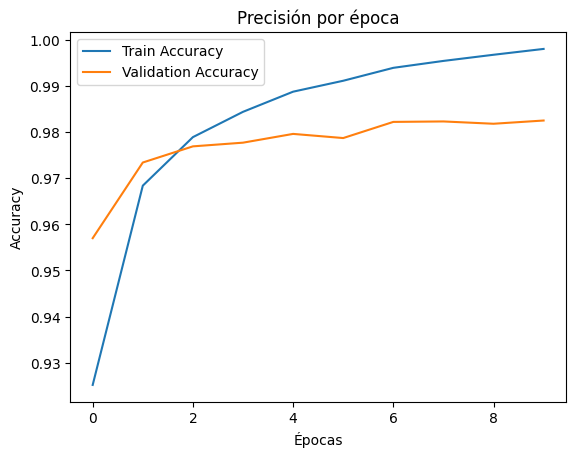

In [7]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Precisión por época')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

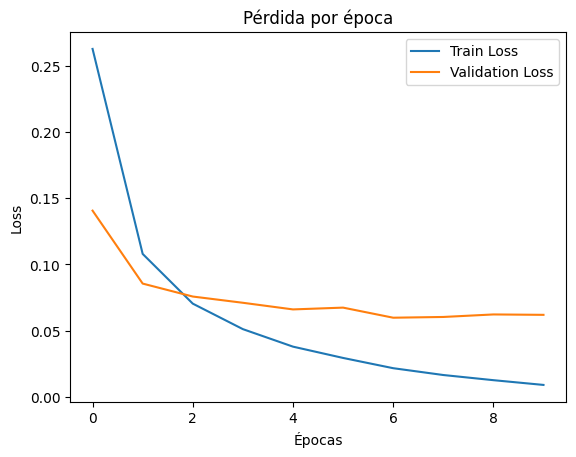

In [8]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Pérdida por época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
model.save("modelo_mnist.h5")

In [10]:
from google.colab import files
uploaded = files.upload()

Saving numero.jpg to numero (1).jpg


In [11]:
import cv2
from keras.models import load_model

model = load_model("modelo_mnist.h5")

img = cv2.imread("numero.jpg")

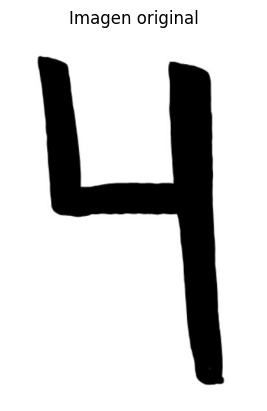

In [12]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")
plt.axis("off")
plt.show()

In [13]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.resize(img, (28, 28))
img = cv2.bitwise_not(img)
_, img = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY_INV)

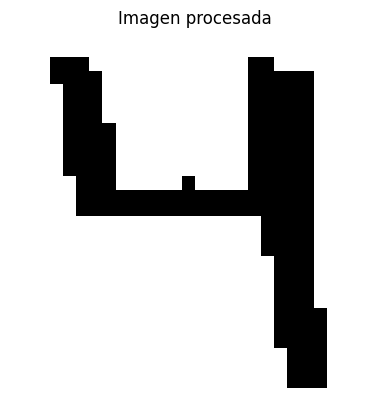

In [14]:
plt.imshow(img, cmap='gray')
plt.title("Imagen procesada")
plt.axis("off")
plt.show()

In [16]:
import cv2
import numpy as np
from keras.models import load_model

# cargar modelo
model = load_model("modelo_mnist.h5")

# cargar imagen desde archivo
img = cv2.imread("numero.jpg")  # ← tu imagen aquí

# ===== PREPROCESAMIENTO =====
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.resize(img, (28, 28))
img = cv2.bitwise_not(img)

_, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

img = img.astype('float32') / 255
img = img.reshape(1, 28*28)

# ===== PREDICCIÓN =====
pred = model.predict(img)
numero = np.argmax(pred)

print("Número detectado:", numero)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Número detectado: 4
